# 01 - Before / After Preprocessing

Notebook này so sánh nhanh raw train split với cleaned train split.

Trọng tâm:
- giữ ít code hơn
- rút ra nhiều insight hơn
- xem được hiệu quả của preprocessing ngay trên text, labels, và noise

In [1]:
from pathlib import Path
import json

from IPython import get_ipython
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "legend.frameon": False,
    }
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

SENTIMENT_MAP = {0: "negative", 1: "neutral", 2: "positive"}
SENTIMENT_COLORS = {0: "#d64b4b", 1: "#f0ad4e", 2: "#2ca02c"}
SENTIMENT_ORDER = [0, 1, 2]


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
        if (candidate / "preprocessing_pipeline.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Cannot locate project root")


def style_axes(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, color="#dfe3eb", linewidth=0.8, alpha=0.9)


def annotate_vertical_bars(ax, bars, values, fmt="{:,.0f}"):
    values = list(values)
    peak = max(values) if values else 0
    offset = peak * 0.02 if peak else 0.1
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=9,
        )


ROOT = find_project_root()
RAW_TRAIN = ROOT / "data/interim/raw_train/train.json"
CLEAN_TRAIN = ROOT / "data/processed/train_clean.json"
RAW_SCAN = ROOT / "experiments/reports/train_scan.json"
CLEAN_SCAN = ROOT / "experiments/reports/train_clean_scan.json"

raw_df = pd.read_json(RAW_TRAIN)
clean_df = pd.read_json(CLEAN_TRAIN)
raw_report = json.loads(RAW_SCAN.read_text(encoding="utf-8"))
clean_report = json.loads(CLEAN_SCAN.read_text(encoding="utf-8"))

print(f"raw rows: {len(raw_df)}")
print(f"clean rows: {len(clean_df)}")
print(f"rows removed: {len(raw_df) - len(clean_df)}")


raw rows: 10728
clean rows: 10696
rows removed: 32


In [2]:
def extract_metrics(report: dict) -> dict:
    checks = report["checks"]
    return {
        "rows": report["metadata"]["row_count"],
        "missing_content": checks["missing_values"]["per_column"]["content"]["missing_count"],
        "short_texts": checks["length"]["shorter_than_min_length"],
        "encoding_rows": checks["encoding"]["rows_with_any_issue"],
        "noise_rows": checks["noise_patterns"]["rows_with_any_noise"],
        "emoji_rows": checks["emoji"]["rows_with_emoji"],
        "duplicates": checks["duplicates"]["normalized_duplicate_texts"],
    }


summary = pd.DataFrame(
    [extract_metrics(raw_report), extract_metrics(clean_report)],
    index=["raw", "clean"],
).T

label_before = raw_df["sentiment_llm"].value_counts().sort_index()
label_after = clean_df["sentiment_llm"].value_counts().sort_index()
label_compare = pd.DataFrame({"raw": label_before, "clean": label_after}).fillna(0).astype(int)

raw_len = raw_df["content"].fillna("").str.len()
clean_len = clean_df["content"].fillna("").str.len()
raw_words = raw_df["content"].fillna("").str.split().map(len)
clean_words = clean_df["content"].fillna("").str.split().map(len)

display(summary)
display(label_compare)

,raw,clean
rows,10728,10696
missing_content,6,0
short_texts,14,0
encoding_rows,212,23
noise_rows,768,649
emoji_rows,338,0
duplicates,11,0


,raw,clean
sentiment_llm,,
0,5622,5608
1,1749,1744
2,3357,3344


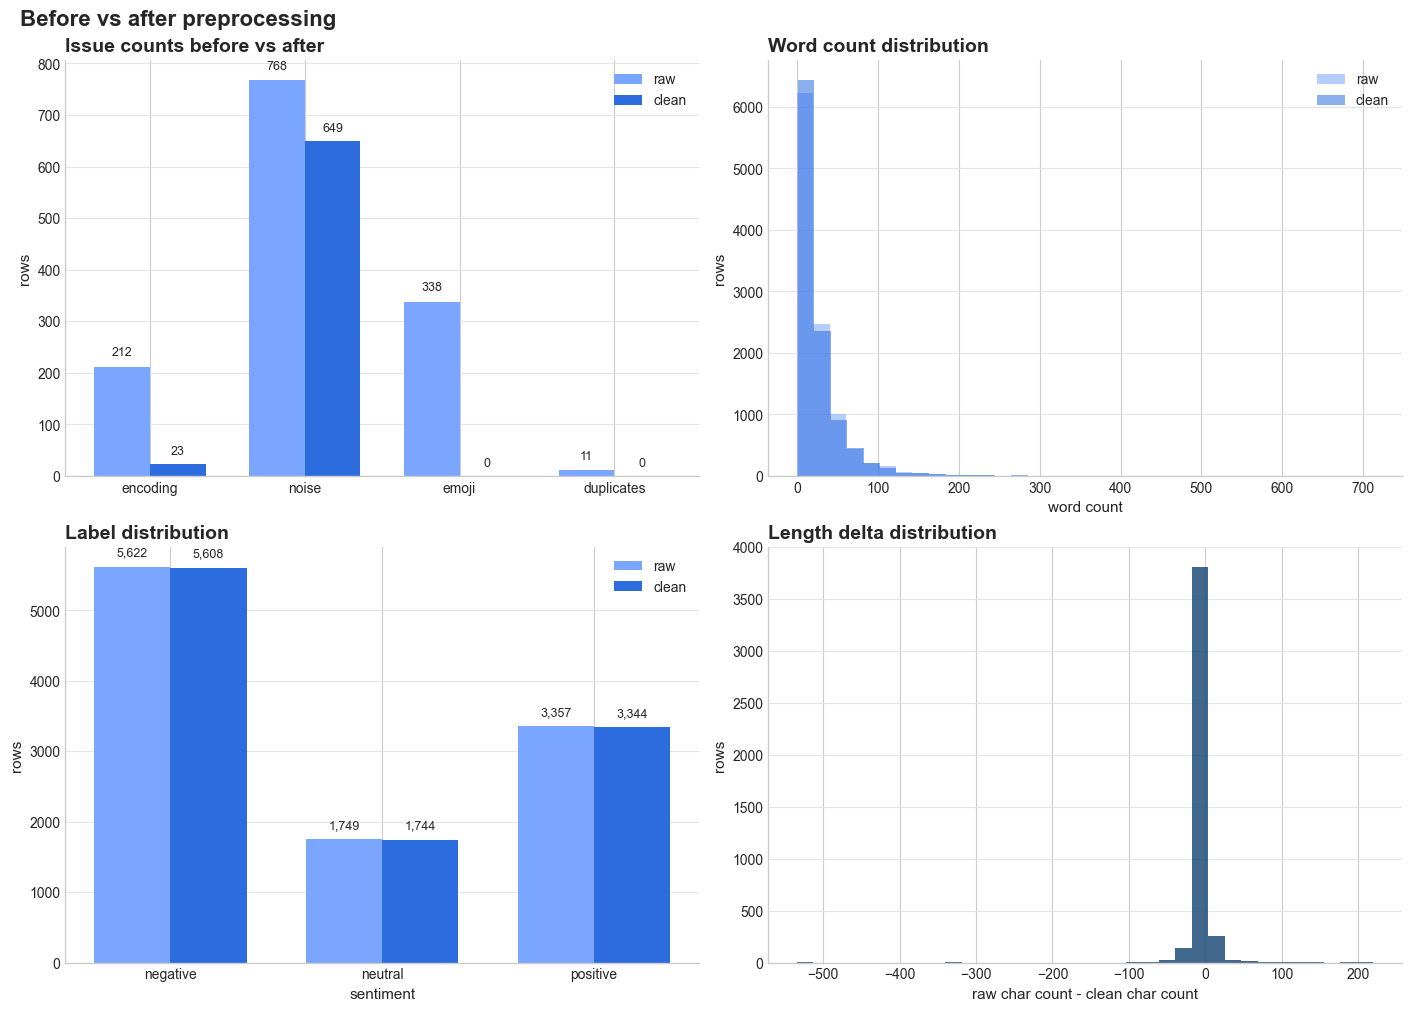

In [3]:
issue_df = pd.DataFrame(
    {
        "raw": [
            raw_report["checks"]["encoding"]["rows_with_any_issue"],
            raw_report["checks"]["noise_patterns"]["rows_with_any_noise"],
            raw_report["checks"]["emoji"]["rows_with_emoji"],
            raw_report["checks"]["duplicates"]["normalized_duplicate_texts"],
        ],
        "clean": [
            clean_report["checks"]["encoding"]["rows_with_any_issue"],
            clean_report["checks"]["noise_patterns"]["rows_with_any_noise"],
            clean_report["checks"]["emoji"]["rows_with_emoji"],
            clean_report["checks"]["duplicates"]["normalized_duplicate_texts"],
        ],
    },
    index=["encoding", "noise", "emoji", "duplicates"],
)

changed = clean_df.loc[clean_df["content_raw"].fillna("") != clean_df["content"].fillna("")].copy()
changed["raw_len"] = changed["content_raw"].fillna("").str.len()
changed["clean_len"] = changed["content"].fillna("").str.len()
changed["delta"] = changed["raw_len"] - changed["clean_len"]
changed["word_delta"] = changed["content_raw"].fillna("").str.split().map(len) - changed["content"].fillna("").str.split().map(len)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle("Before vs after preprocessing", x=0.01, ha="left", fontsize=16, fontweight="bold")

# Issue counts before vs after
ax = axes[0, 0]
x = np.arange(len(issue_df.index))
width = 0.36
raw_bars = ax.bar(x - width / 2, issue_df["raw"], width=width, label="raw", color="#7aa6ff")
clean_bars = ax.bar(x + width / 2, issue_df["clean"], width=width, label="clean", color="#2d6cdf")
ax.set_xticks(x)
ax.set_xticklabels(issue_df.index)
style_axes(ax)
ax.set_title("Issue counts before vs after", loc="left")
ax.set_ylabel("rows")
ax.legend(frameon=False)
annotate_vertical_bars(ax, raw_bars, issue_df["raw"].tolist())
annotate_vertical_bars(ax, clean_bars, issue_df["clean"].tolist())

# Word count distribution
ax = axes[0, 1]
ax.hist(raw_words, bins=35, alpha=0.55, label="raw", color="#7aa6ff")
ax.hist(clean_words, bins=35, alpha=0.55, label="clean", color="#2d6cdf")
style_axes(ax)
ax.set_title("Word count distribution", loc="left")
ax.set_xlabel("word count")
ax.set_ylabel("rows")
ax.legend(frameon=False)

# Label distribution
ax = axes[1, 0]
label_x = np.arange(len(label_compare.index))
label_width = 0.36
sentiment_labels = [SENTIMENT_MAP.get(int(v), str(v)) for v in label_compare.index.tolist()]
raw_label_bars = ax.bar(label_x - label_width / 2, label_compare["raw"], width=label_width, label="raw", color="#7aa6ff")
clean_label_bars = ax.bar(label_x + label_width / 2, label_compare["clean"], width=label_width, label="clean", color="#2d6cdf")
ax.set_xticks(label_x)
ax.set_xticklabels(sentiment_labels)
style_axes(ax)
ax.set_title("Label distribution", loc="left")
ax.set_xlabel("sentiment")
ax.set_ylabel("rows")
ax.legend(frameon=False)
annotate_vertical_bars(ax, raw_label_bars, label_compare["raw"].tolist())
annotate_vertical_bars(ax, clean_label_bars, label_compare["clean"].tolist())

# Length delta distribution
ax = axes[1, 1]
ax.hist(changed["delta"], bins=35, color="#1f4e79", alpha=0.85)
style_axes(ax)
ax.set_title("Length delta distribution", loc="left")
ax.set_xlabel("raw char count - clean char count")
ax.set_ylabel("rows")

plt.show()


,review_id,product_name,sentiment_llm,raw_len,clean_len,delta,content_raw,content
1137,12593634,Sách Sinh Học Phân Tử Của Tế Bào - Sự Sinh Trưởng Và Phát Triển Của Tế Bào (Tập 5),1,255,36,219,Sách được bao gói tốt. Tớ chưa đọc...................................................................................................,Sách được bao gói tốt. Tớ chưa đọc..
1010,10645258,Combo 2 Cuốn: How To Crack The IELTS Speaking +Writing Test,2,1907,1710,197,"Nhìn chung, đây là bộ sách hay được đầu tư công phu về mặt thiết kế và nội dung. Sau 1 tuần sử dụng, mình nhận thấy có sự khác nhau khá ...","Nhìn chung, đây là bộ sách hay được đầu tư công phu về mặt thiết kế và nội dung. Sau 1 tuần sử dụng, mình nhận thấy có sự khác nhau khá ..."
2758,9948743,Sách Muôn Kiếp Nhân Sinh 2,1,3185,3042,143,"(Quan điểm cá nhân)\n- Đánh giá nội dung: Khá\n- Loại sách: xếp vào loại sách tiểu thuyết với chất liệu lịch sử, luân hồi, nhân quả..., ...","(Quan điểm cá nhân) - Đánh giá nội dungemoji_kh_lo_i_s_ch xếp vào loại sách tiểu thuyết với chất liệu lịch sử, luân hồi, nhân quả.., sẽ ..."
6402,760289,Sách Thiền Và Nghệ Thuật Bảo Dưỡng Xe Máy,2,2905,2764,141,Cuốn sách là cuộc hành trình đi tìm ý nghĩa hay định nghĩa Phẩm Chất (Quality) của nhân vật tên là Phaedrus. Phẩm chất (quality) là gì? ...,Cuốn sách là cuộc hành trình đi tìm ý nghĩa hay định nghĩa Phẩm Chất (Quality) của nhân vật tên là Phaedrus. Phẩm chất (quality) là gì? ...
9881,8244920,Sách Chuyện Nhỏ Sài Gòn Bao Nhớ,0,1076,947,129,Không biết đã có khách hàng nào góp ý về số lượng emails Tiki chuyển tải tới khách mua cho mỗi đơn hàng hay không ? tôi...,Không biết đã có khách hàng nào góp ý về số lượng emails Tiki chuyển tải tới khách mua cho mỗi đơn hàng hay không ? tôi đặt mua 1 đơn hà...
6663,5386929,Sách Hai Mặt Của Gia Đình,2,2678,2557,121,"Khi nhắc tới chủ đề gia đình, mình nghĩ ngay tới cuốn Hai mặt của gia đình – Choi Kwanghyun. Sách theo thể loại tâm lý học, thêm những c...","Khi nhắc tới chủ đề gia đình, mình nghĩ ngay tới cuốn Hai mặt của gia đình – Choi Kwanghyun. Sách theo thể loại tâm lý học, thêm những c..."
4031,8300170,Sách Án Mạng Mười Một Chữ,0,764,657,107,"Truyện nhiều nhân vật quá rối cho người đọc. Còn về nội dung thì theo kiểu penthouse quá, nó là cho người đọc cảm thấ...","Truyện nhiều nhân vật quá rối cho người đọc. Còn về nội dung thì theo kiểu penthouse quá, nó là cho người đọc cảm thấm tác giả quá ép bu..."
4324,770365,Truyện đọc tiếng Anh - Wordsworth Editions: The Little Prince,1,768,666,102,Một cuốn sách ngoại văn 50k thì rất khó để yêu cầu nó hoàn mỹ được rồi =)))\nCó vài bạn sẽ phàn nàn giấy mỏng dín...,"Một cuốn sách ngoại văn 50k thì rất khó để yêu cầu nó hoàn mỹ được rồi =))) Có vài bạn sẽ phàn nàn giấy mỏng dính, màu tối như sách cũng..."
8438,10304804,Sách Khi Lỗi Thuộc Về Những Vì Sao (Tái Bản),0,699,603,96,Theo cảm nhận của riêng mình cuốn sách này k hay và cũng k thực sự đặc sắc. Lúc đầu nghe mô tả mình đã nghĩ nó sẽ c...,Theo cảm nhận của riêng mình cuốn sách này không hay và cũng không thực sự đặc sắc. Lúc đầu nghe mô tả mình đã nghĩ nó sẽ cảm động và th...
4504,1178542,Sách Tự Học Tiếng Nhật Dành Cho Người Mới Bắt Đầu (Kèm CD Hoặc Dùng App),0,135,50,85,"TIKI giao hàng không đúng đơn hàng,không có CD.\n.......................................................................................","TIKI giao hàng không đúng đơn hàng,không có cd. .."


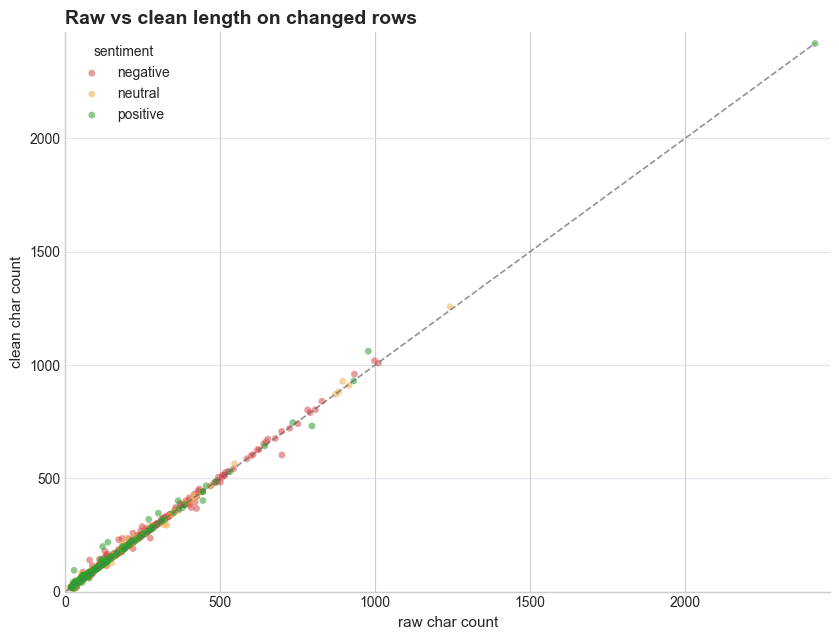

,product_name,rows,avg_delta,avg_words_delta
0,Mình Chỉ Là Người Bình Thường (Sách Tô Màu),131,-4.526718,0.198473
1,Sách Hai Mặt Của Gia Đình,81,-1.222222,5.740741
2,Sách Barron's Essential Words For The Toeic (Tái Bản),59,-2.271186,1.559322
3,Sách Sức Mạnh Tiềm Thức (Tái Bản) (Bìa Mềm),55,-4.563636,0.309091
4,Combo Doraemon - Truyện Dài (Trọn Bộ 24 Cuốn) - Tái Bản,54,-1.185185,0.000000
5,Sách Những Người Hàng Xóm - Bản Thường - Bìa Mềm (Tặng kèm Bookmark + Thẻ treo),44,-1.818182,3.159091
6,Sách Đắc Nhân Tâm (Khổ Lớn),44,-3.340909,0.045455
7,"\t Sách Mùa hè không tên (Nguyễn Nhật Ánh) - Tặng kèm Bookmark, Tranh màu",43,-11.046512,0.000000
8,Sách Xứ Cát,42,-7.261905,1.452381
9,Sách Tôn Tử Binh Pháp ( Tái Bản ),40,-2.450000,0.075000


In [4]:
changed = clean_df.loc[clean_df["content_raw"].fillna("") != clean_df["content"].fillna("")].copy()
changed["raw_len"] = changed["content_raw"].fillna("").str.len()
changed["clean_len"] = changed["content"].fillna("").str.len()
changed["delta"] = changed["raw_len"] - changed["clean_len"]
changed["word_delta"] = changed["content_raw"].fillna("").str.split().map(len) - changed["content"].fillna("").str.split().map(len)

top_changed = changed.sort_values("delta", ascending=False).head(10)
display(top_changed[["review_id", "product_name", "sentiment_llm", "raw_len", "clean_len", "delta", "content_raw", "content"]])

sample_changed = changed.sample(min(len(changed), 800), random_state=42)
fig, ax = plt.subplots(figsize=(8.5, 6.5))
for label in SENTIMENT_ORDER:
    subset = sample_changed.loc[sample_changed["sentiment_llm"] == label]
    if subset.empty:
        continue
    ax.scatter(
        subset["raw_len"],
        subset["clean_len"],
        s=24,
        alpha=0.55,
        label=SENTIMENT_MAP.get(label, str(label)),
        color=SENTIMENT_COLORS[label],
        edgecolors="none",
    )

max_len = max(sample_changed["raw_len"].max(), sample_changed["clean_len"].max()) if not sample_changed.empty else 1
ax.plot([0, max_len], [0, max_len], linestyle="--", linewidth=1.2, color="#666666", alpha=0.7)
style_axes(ax)
ax.set_title("Raw vs clean length on changed rows", loc="left")
ax.set_xlabel("raw char count")
ax.set_ylabel("clean char count")
ax.set_xlim(0, max_len * 1.02 if max_len else 1)
ax.set_ylim(0, max_len * 1.02 if max_len else 1)
ax.legend(frameon=False, title="sentiment")
plt.tight_layout()
plt.show()

product_summary = (
    changed.groupby("product_name")
    .agg(rows=("review_id", "count"), avg_delta=("delta", "mean"), avg_words_delta=("word_delta", "mean"))
    .sort_values(["rows", "avg_delta"], ascending=[False, False])
    .head(15)
    .reset_index()
)
display(product_summary)


## Takeaways

- `content` dược làm sạch mạnh phần kỹ thuật, nhưng vẫn giữ tín hiệu sentiment như emoji và dấu nhấn.
- Label distribution gần như giữ nguyên sau clean.
- `raw_len - clean_len` cho thấy preprocessing chủ yếu dọn noise, không làm mất quá nhiều nội dung.
- Những product có nhiều review và delta lớn thường là nơi dữ liệu bẩn hoặc có tín hiệu cảm xúc mạnh.